# Project 3 - Weather Data Analysis

**Domain:** Weather  
**Period:** 2022-2024  
**Scope:** Six Indian cities; simulated daily data.

## 1. Setup and loading

In [1]:
from pathlib import Path
import sys,pandas as pd,numpy as np
ROOT=Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
from src.weather_analysis import validate_weather_data,clean_weather_data,calculate_weather_kpis
raw=pd.read_csv(ROOT/'data/project3_weather/weather_daily_raw.csv')
raw.head()

,date,city,region,temperature_max_c,temperature_min_c,rainfall_mm,humidity_pct,wind_speed_kmh,weather_condition
0,2022-01-01,Delhi,North,19.0,7.8,0.0,60.4,2.9,Clear
1,2022-01-02,Delhi,North,20.3,10.0,0.0,56.1,2.5,Clear
2,2022-01-03,Delhi,North,19.5,9.3,0.0,40.7,2.5,Clear
3,2022-01-04,Delhi,North,15.0,5.7,0.0,51.2,15.2,Clear
4,2022-01-05,Delhi,North,17.3,5.7,0.0,56.5,17.6,Clear


## 2. Data quality

In [2]:
raw_validation=validate_weather_data(raw)
pd.Series(raw_validation)

rows                                                                           6578
columns                                                                           9
missing_required_columns                                                         []
duplicate_city_dates                                                              2
missing_values                    {'rainfall_mm': 1, 'humidity_pct': 1, 'wind_sp...
invalid_dates                                                                     0
negative_rainfall_rows                                                            0
invalid_humidity_rows                                                             0
negative_wind_rows                                                                0
invalid_temperature_order_rows                                                    0
dtype: object

In [3]:
weather=clean_weather_data(raw)
print(f'{len(raw):,} raw rows -> {len(weather):,} clean observations')
validate_weather_data(weather)

6,578 raw rows -> 6,576 clean observations


{'rows': 6576,
 'columns': 21,
 'missing_required_columns': [],
 'duplicate_city_dates': 0,
 'missing_values': {},
 'invalid_dates': 0,
 'negative_rainfall_rows': 0,
 'invalid_humidity_rows': 0,
 'negative_wind_rows': 0,
 'invalid_temperature_order_rows': 0}

## 3. Descriptive statistics and KPIs

In [4]:
kpis=calculate_weather_kpis(weather)
pd.Series(kpis).to_frame('Value')

,Value
observations,6576
cities,6
start_date,2022-01-01
end_date,2024-12-31
mean_temperature_c,25.82
median_temperature_c,25.8
total_rainfall_mm,97416.1
rainy_days,1977
extreme_event_days,904
heatwave_days,439


In [5]:
weather[['temperature_max_c','temperature_min_c','temperature_mean_c','rainfall_mm','humidity_pct','wind_speed_kmh']].describe().round(2)

,temperature_max_c,temperature_min_c,temperature_mean_c,rainfall_mm,humidity_pct,wind_speed_kmh
count,6576.00,6576.00,6576.00,6576.00,6576.00,6576.00
mean,30.01,21.64,25.82,14.81,58.45,11.50
std,5.91,5.99,5.84,37.10,14.05,6.78
min,13.70,3.20,8.65,0.00,20.90,0.20
25%,25.80,18.10,21.95,0.00,48.30,6.50
50%,29.70,22.10,25.80,0.00,56.00,10.30
75%,33.90,26.10,29.96,6.12,67.50,15.12
max,48.40,37.10,41.85,333.70,100.00,55.00


## 4. Temperature and seasonal analysis

In [6]:
weather.groupby(['city','season']).temperature_mean_c.agg(['mean','median','min','max']).round(2)

mean  median    min    max
city      season                                   
Bengaluru Monsoon       25.47   25.45  21.15  30.00
          Post-Monsoon  22.18   22.25  17.10  26.80
          Summer        22.93   22.90  15.90  29.25
          Winter        20.39   20.50  15.85  25.10
Chennai   Monsoon       31.13   31.20  24.95  36.05
          Post-Monsoon  27.07   26.95  20.75  32.20
          Summer        27.92   27.88  21.75  34.95
          Winter        24.48   24.55  18.30  29.35
Delhi     Monsoon       34.47   34.95  25.30  41.70
          Post-Monsoon  21.59   21.40  13.40  29.60
          Summer        25.19   25.65  12.40  36.65
          Winter        14.13   14.05   8.65  19.60
Jaipur    Monsoon       34.79   35.28  26.05  41.85
          Post-Monsoon  22.97   22.90  14.85  32.20
          Summer        26.05   25.82  14.65  37.00
          Winter        16.12   16.05  10.65  21.15
Kolkata   Monsoon       30.74   30.75  24.10  37.05
          Post-Monsoon  24.26   24.15  18.50  30.40
          Summer        26.02   25.72  18.95  34.10
          Winter        20.39   20.35  15.40  25.60
Mumbai    Monsoon       29.82   29.90  25.00  34.50
          Post-Monsoon  26.27   26.15  21.40  31.60
          Summer        27.07   27.08  20.20  33.70
          Winter        23.79   23.70  18.80  29.45

In [7]:
weather.groupby(['year','city']).temperature_mean_c.mean().unstack().round(2)

city,Bengaluru,Chennai,Delhi,Jaipur,Kolkata,Mumbai
year,,,,,,
2022,22.93,27.93,24.91,26.03,25.84,27.06
2023,23.05,28.09,25.07,25.91,26.01,27.06
2024,23.10,27.99,24.87,26.06,25.87,27.01


## 5. Rainfall distribution

In [8]:
weather.groupby(['city','season']).rainfall_mm.agg(['sum','mean','median','max']).round(2)

sum   mean  median    max
city      season                                     
Bengaluru Monsoon       10282.1  28.09    0.00  273.6
          Post-Monsoon    390.8   2.14    0.00   57.3
          Summer         5559.6  20.14    0.00  289.3
          Winter           34.0   0.13    0.00    5.2
Chennai   Monsoon        3525.9   9.63    0.00  116.9
          Post-Monsoon   9469.8  51.75   37.20  333.7
          Summer          126.5   0.46    0.00   14.0
          Winter         4365.8  16.11    0.00  268.8
Delhi     Monsoon       16307.4  44.56   21.15  289.4
          Post-Monsoon    385.5   2.11    0.00   41.0
          Summer           45.8   0.17    0.00    9.7
          Winter           40.5   0.15    0.00    9.3
Jaipur    Monsoon       13774.2  37.63    9.40  310.1
          Post-Monsoon    349.5   1.91    0.00   80.8
          Summer           21.2   0.08    0.00    4.3
          Winter           23.0   0.08    0.00    6.6
Kolkata   Monsoon       14861.7  40.61   19.10  290.1
          Post-Monsoon   1087.1   5.94    0.00   84.4
          Summer          115.8   0.42    0.00    7.5
          Winter           86.5   0.32    0.00   12.1
Mumbai    Monsoon       15235.1  41.63   18.55  312.4
          Post-Monsoon   1125.6   6.15    0.00   53.2
          Summer          103.5   0.38    0.00   13.6
          Winter           99.2   0.37    0.00   11.2

## 6. Extreme events

In [9]:
weather.groupby('city')[['heatwave_day','heavy_rain_day','cold_day','high_wind_day','extreme_event']].sum().astype(int)

,heatwave_day,heavy_rain_day,cold_day,high_wind_day,extreme_event
city,,,,,
Bengaluru,0,98,0,2,99
Chennai,0,86,0,3,88
Delhi,210,103,10,1,269
Jaipur,227,84,2,1,270
Kolkata,2,88,0,3,92
Mumbai,0,83,0,3,86


## 7. Correlation

In [10]:
weather[['temperature_mean_c','temperature_range_c','rainfall_mm','humidity_pct','wind_speed_kmh']].corr().round(3)

,temperature_mean_c,temperature_range_c,rainfall_mm,humidity_pct,wind_speed_kmh
temperature_mean_c,1.000,-0.038,0.284,0.300,0.118
temperature_range_c,-0.038,1.000,-0.004,-0.029,-0.020
rainfall_mm,0.284,-0.004,1.000,0.536,0.208
humidity_pct,0.300,-0.029,0.536,1.000,0.205
wind_speed_kmh,0.118,-0.020,0.208,0.205,1.000


## 8. Visualizations

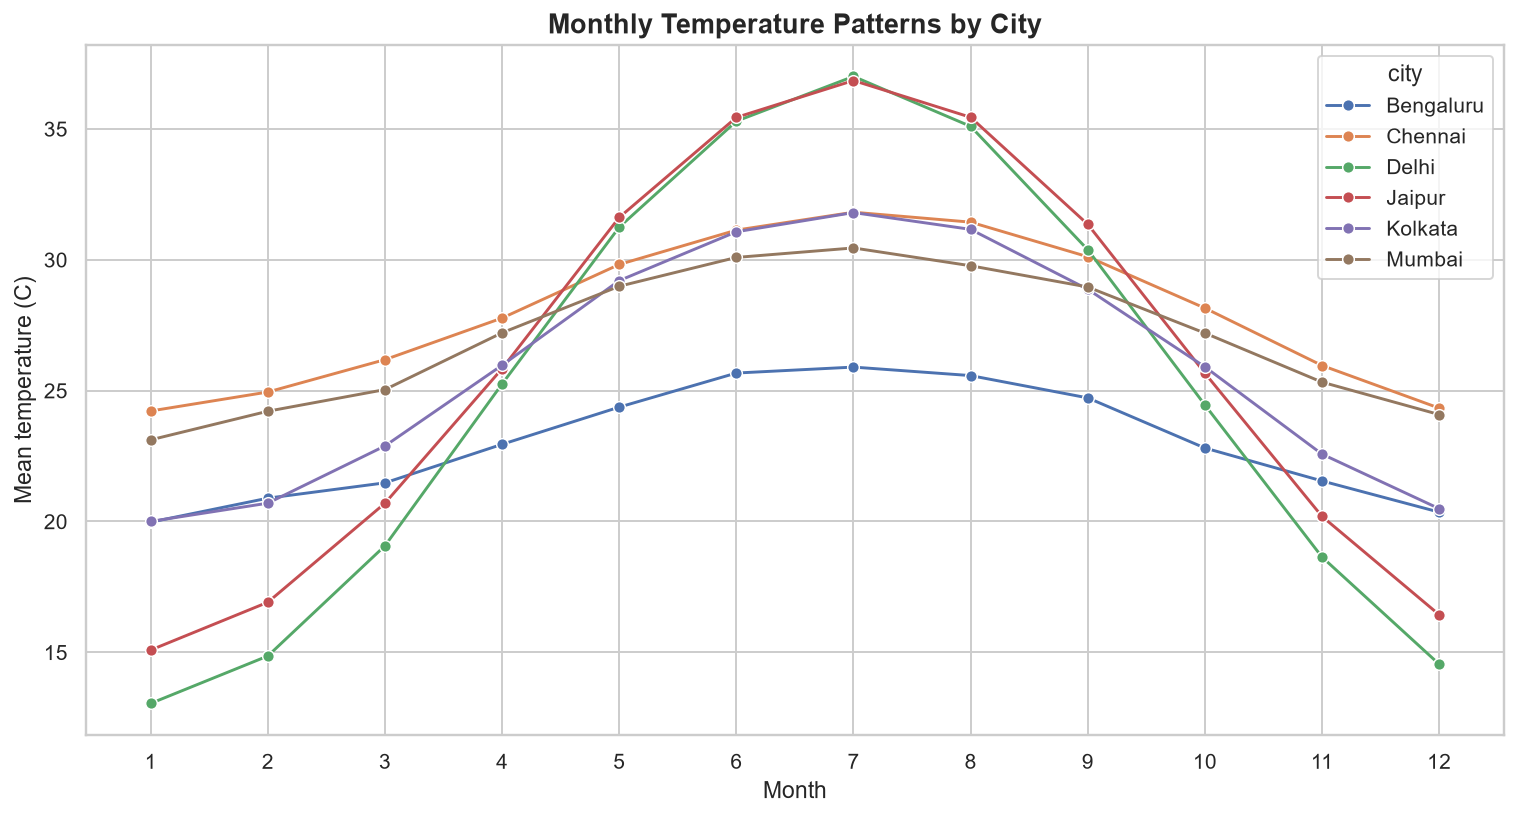

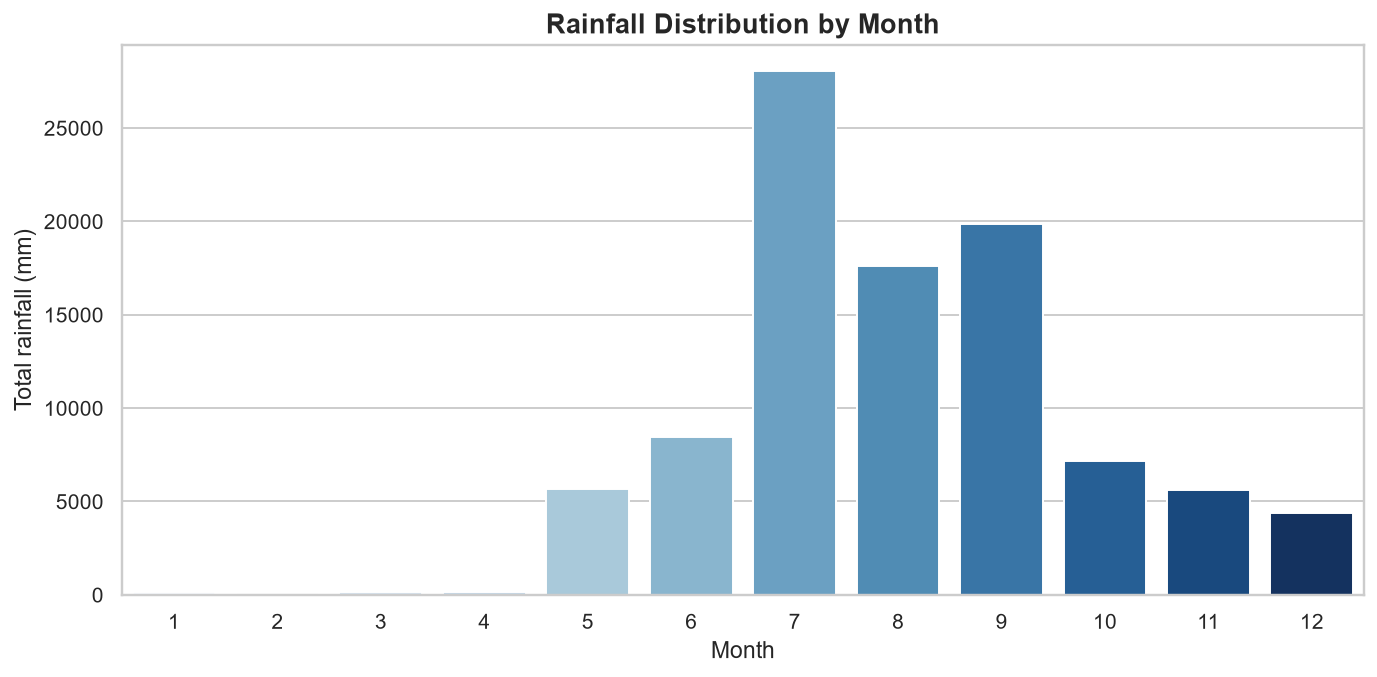

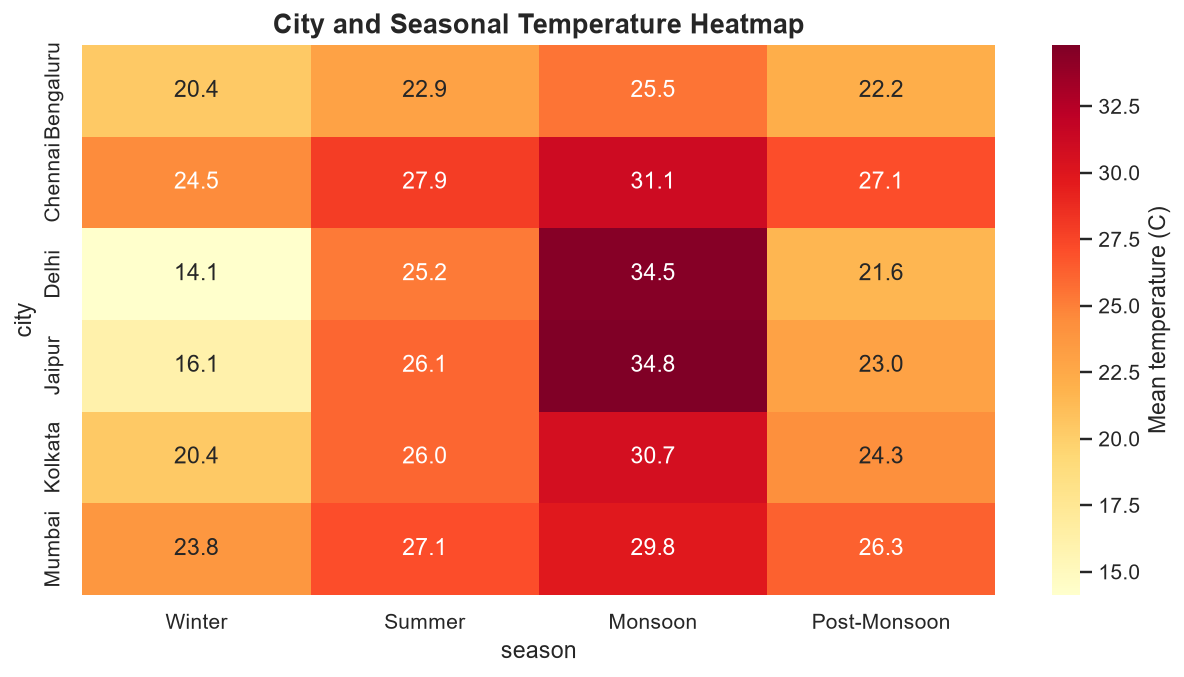

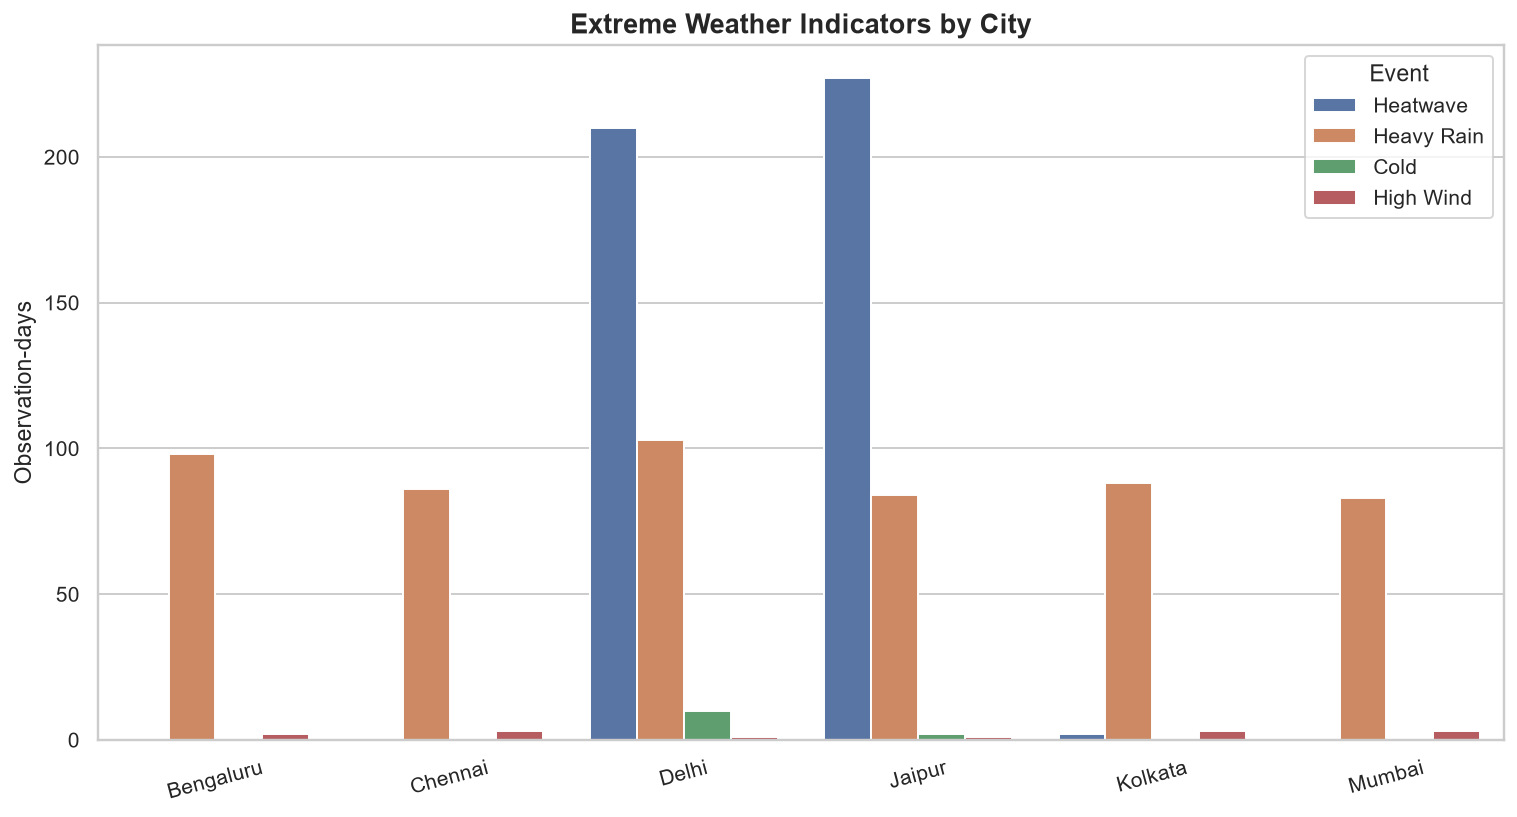

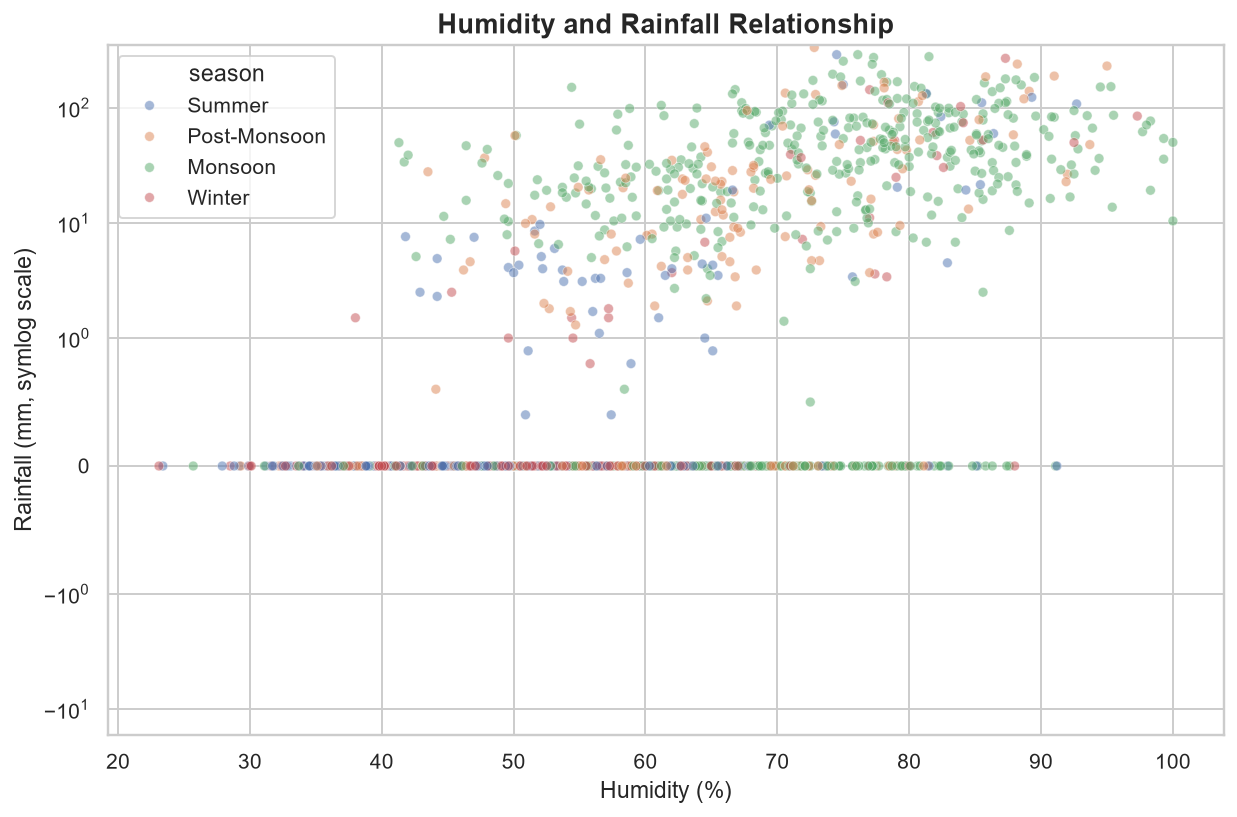

In [11]:
from IPython.display import display,Image
for chart in sorted((ROOT/'visualizations/project3_weather').glob('*.png')): display(Image(filename=str(chart),width=850))

## 9. Recommendations
1. Prepare city-specific heat and rainfall response calendars.
2. Inspect drainage before peak rainfall months.
3. Trigger heat readiness as temperatures approach 40 C.
4. Use local, not portfolio-wide, thresholds.
5. Replace simulated data with verified official observations for operational use.

## 10. Limitations
The data is simulated and thresholds are analytical portfolio rules. Correlation is descriptive and does not establish causality.